In [47]:
# Select the NACA profile to analyze
profile = 'naca0012'  # Change this to 'naca23012' or 'naca2412' as needed

In [48]:
# %matplotlib notebook
from matplotlib import pyplot as plt

import pandas as pd
import numpy as np
import os
import re

In [49]:
def extract_cl(fname, tol=1e-5):
    if not os.path.exists(fname):
        print(f'Skipping missing force file: {fname}')
        return np.nan

    try:
        raw = pd.read_csv(fname)
    except pd.errors.EmptyDataError:
        print(f'Skipping empty force file: {fname}')
        return np.nan

    if raw.empty or 'cl_p' not in raw.columns:
        print(f'Skipping malformed force file: {fname}')
        return np.nan

    if 'iter' in raw:
        raw = raw.set_index('iter')

    if 'cl_v' in raw:
        cl = raw['cl_p'] + raw['cl_v']
    else:
        cl = raw['cl_p']

    if cl.empty:
        print(f'Skipping force file with no CL entries: {fname}')
        return np.nan

    cl_last = cl.iloc[-1]

    window_mean = cl.tail(min(len(cl), 20)).mean()
    if abs(cl_last - window_mean) > tol:
        print('Warning, cl is not converged : {}'.format(fname))

    return cl_last

In [50]:
def check_convergence(fname):
    """Check CFD convergence by plotting residuals from stats.csv"""
    stats = pd.read_csv(fname)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.semilogy(stats['iter'], stats['rho'], label='rho residual')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (log scale)')
    ax.set_title('CFD Convergence History')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    
    # Check if converged (residual drops significantly)
    initial_residual = stats['rho'].iloc[0]
    final_residual = stats['rho'].iloc[-1]
    reduction = final_residual / initial_residual
    
    print(f'Initial residual: {initial_residual:.2e}')
    print(f'Final residual: {final_residual:.2e}')
    print(f'Residual reduction: {reduction:.2e}')
    
    if reduction < 1e-4:
        print('✓ Solution appears to be converged')
    else:
        print('⚠ Solution may not be fully converged')
    
    return fig

In [51]:
# Make per-AoA convergence plots and save under <profile>/convergence
profile_dir = f'../{profile}/runs'
aoa_folders = [d for d in os.listdir(profile_dir) if os.path.isdir(os.path.join(profile_dir, d)) and d.startswith('aoa')]

# Extract angle values and sort (handle both positive and negative angles)
aoa_list = []
for folder in aoa_folders:
    # Match aoa-N for negative angles or aoaN for positive angles
    match = re.match(r'aoa(-?\d+)', folder)
    if match:
        aoa_list.append(int(match.group(1)))
aoa_list.sort()

print(f'Found {len(aoa_list)} angle of attack cases: {aoa_list}')

convergence_dir = f'{profile}/convergence'
os.makedirs(convergence_dir, exist_ok=True)

print(f'\nChecking convergence for {profile}')
print('='*60)

for angle in aoa_list:
    stats_path = f'../{profile}/runs/aoa{angle}/stats.csv'
    if not os.path.exists(stats_path):
        print(f'Skipping missing stats file for AoA {angle}: {stats_path}')
        continue

    try:
        stats = pd.read_csv(stats_path)
    except pd.errors.EmptyDataError:
        print(f'Skipping empty stats file for AoA {angle}: {stats_path}')
        continue

    if stats.empty or 'iter' not in stats or 'rho' not in stats:
        print(f'Skipping malformed stats file for AoA {angle}: {stats_path}')
        continue

    # Handle restarts where iter resets to 1 by stitching cumulative iteration
    iter_series = stats['iter']
    resets = (iter_series.diff() <= 0).fillna(False)
    if resets.any():
        offset = 0
        iter_adj = []
        prev_iter = iter_series.iloc[0]
        iter_adj.append(prev_iter)
        for curr in iter_series.iloc[1:]:
            if curr <= prev_iter:
                offset += prev_iter
            iter_adj.append(curr + offset)
            prev_iter = curr
        stats['iter_adj'] = iter_adj
        print(f'Note: detected {int(resets.sum())} iteration reset(s) for AoA {angle}; using cumulative iteration for plotting.')
    else:
        stats['iter_adj'] = iter_series

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.semilogy(stats['iter_adj'], stats['rho'], label=f'AoA {angle}°', linewidth=2)

    initial_residual = stats['rho'].iloc[0]
    final_residual = stats['rho'].iloc[-1]
    reduction = final_residual / initial_residual

    status = '✓' if reduction < 1e-4 else '⚠'
    print(f'{status} AoA {angle:2d}°: {initial_residual:.2e} → {final_residual:.2e} (reduction: {reduction:.2e})')

    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Residual (log scale)', fontsize=12)
    ax.set_title(f'CFD Convergence - {profile} - AoA {angle}°', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    fig.tight_layout()

    out_path = f'{convergence_dir}/aoa{angle}.png'
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

print(f'Per-AoA convergence plots saved to: {convergence_dir}')

Found 41 angle of attack cases: [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Checking convergence for naca0012
Note: detected 1 iteration reset(s) for AoA -20; using cumulative iteration for plotting.
⚠ AoA -20°: 1.00e+00 → 1.19e-02 (reduction: 1.19e-02)
Note: detected 1 iteration reset(s) for AoA -19; using cumulative iteration for plotting.
⚠ AoA -19°: 1.00e+00 → 1.66e-02 (reduction: 1.66e-02)
Note: detected 1 iteration reset(s) for AoA -18; using cumulative iteration for plotting.
⚠ AoA -18°: 1.00e+00 → 1.25e-02 (reduction: 1.25e-02)
Note: detected 1 iteration reset(s) for AoA -17; using cumulative iteration for plotting.
⚠ AoA -17°: 1.00e+00 → 1.62e-02 (reduction: 1.62e-02)
Note: detected 1 iteration reset(s) for AoA -16; using cumulative iteration for plotting.
⚠ AoA -16°: 1.00e+00 → 1.10e-02 (reduction: 1.10e-02)
Note: detected 1 iteration reset(s) for AoA -15

In [52]:
# Use detected AoA list (assumes previous cell was run)
aoa = np.array(aoa_list)
valid_aoa = []
cl = []

for a in aoa:
    val = extract_cl(f'../{profile}/runs/aoa{a}/force_airfoil.csv', tol=5e-4)
    if pd.notna(val):
        valid_aoa.append(a)
        cl.append(val)

aoa = np.array(valid_aoa)
cl = np.array(cl)

Warning, cl is not converged : ../naca0012/runs/aoa-20/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-19/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-18/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-17/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-16/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-15/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-14/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa-13/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa13/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa14/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa15/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa16/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa17/force_airfoil.csv
Warning, cl is not converged : ../naca0012/runs/aoa18/fo

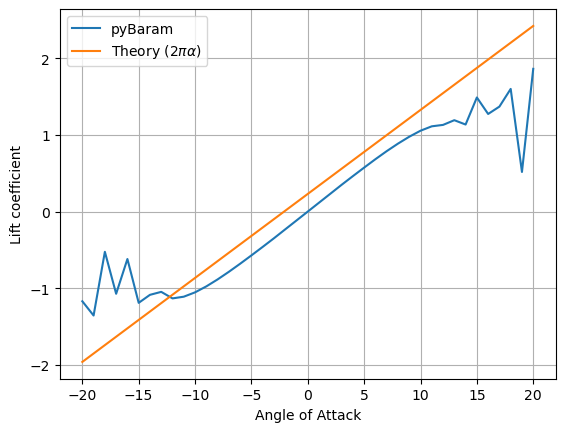

In [53]:
if len(aoa) == 0:
    print('No valid CL data found. Check force_airfoil.csv files in runs/.')
else:
    fig, ax = plt.subplots()
    ax.plot(aoa, cl)
    ax.plot(aoa, 2*np.pi*np.deg2rad(aoa + 2.1))
    ax.set_xlabel('Angle of Attack')
    ax.set_ylabel('Lift coefficient')
    ax.legend(['pyBaram', r'Theory ($2\pi\alpha$)'])
    ax.grid()
    fig.savefig(f'{profile}/cl.png', dpi=300)